# Module 04 - DSS, tối ưu vận tải và Power BI pack

**Câu hỏi.** Sau khi có xác suất trễ, làm sao biến nó thành *quyết định
hành động* (theo dõi/điều phối) một cách minh bạch và có thể giải thích?

**Phương pháp.** Tầng prescriptive 3 bước: (1) `delay_risk_score` =
trộn có trọng số xác suất mô hình với các "áp lực" vận hành; (2) phân
`priority` Low/Medium/High theo ngưỡng; (3) gán tài xế giả lập theo chi
phí tối thiểu. Mỗi bước đều được *kiểm chứng* và *bóc tách*.

**Quyết định đầu ra.** Hàng đợi ưu tiên + hành động khuyến nghị + gán
tài xế kịch bản.

> **Đối tượng & cách đọc.** Notebook cho **người mới** trong nhóm. Lời
> giải thích bằng tiếng Việt; thuật ngữ tiếng Anh (F2, MCC, bootstrap…)
> được định nghĩa ở mục **"0. Định nghĩa"** và đầy đủ trong
> `docs/GLOSSARY.md`. Mỗi mục theo mạch *mục tiêu → phân tích → insight*;
> mỗi bảng/biểu đồ có **một dòng đọc-hiểu ngay bên dưới**.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import Image
from pizza_dss.config import PRIORITY_LOW_MAX, PRIORITY_MEDIUM_MAX
from pizza_dss.dashboard_data import build_dashboard_data
from pizza_dss.data_loader import load_processed_splits
from pizza_dss.decision_rules import (
    calculate_delay_risk_components,
    calculate_delay_risk_score,
    explain_delay_risk_score,
    get_priority_level,
)
from pizza_dss.modeling import load_best_model, predict_delay_probability
from pizza_dss.powerbi import build_powerbi_pack
from pizza_dss.transport_optimization import (
    build_transport_artifacts,
    solve_transport_assignment,
    transport_cost_policy_spec,
)

## 0. Định nghĩa tầng DSS

- **Delay Risk Score (0-100)** = `0.55*P(trễ)` + `0.15*traffic` +
  `0.12*distance` + `0.08*peak` + `0.06*complexity` + `0.04*weekend`.
  Trọng số là **chính sách minh bạch** do nhóm chọn (ưu tiên tín hiệu mô
  hình), không phải tối ưu thống kê.
- **Priority**: Low nếu score ≤ 35, Medium nếu ≤ 65, còn lại High
  (ngưỡng `PRIORITY_LOW_MAX` / `PRIORITY_MEDIUM_MAX` trong `config`).
- **Calibration**: kiểm tra đơn risk cao có *thực sự* trễ nhiều hơn
  không (so risk band với delay rate thật).
- **Bài toán phân công (assignment)**: gán đơn ↔ tài xế sao cho tổng chi
  phí nhỏ nhất (Hungarian; greedy nếu thiếu scipy).

## 0b. Risk component policy spec

**Vì sao bước này?**
- Làm gì: Liệt kê từng thành phần của Risk Score, công thức chuẩn hóa về 0-100, trọng số và lý do chọn.
- Vì sao: Risk Score là policy DSS do nhóm thiết kế, không phải tham số học tự động. Nếu không có bảng này, người xem chỉ thấy một con số 0-100 nhưng không biết nó đến từ đâu.
- Kỹ thuật: Weighted scoring model, normalization về cùng thang 0-100.
- Bằng chứng dẫn tới: `reports/metrics/risk_component_policy_spec.csv` là artifact chuẩn; tổng weight = 1.0 và `risk_component_breakdown.csv` cho thấy contribution cộng lại đúng bằng score.

In [2]:
queue = build_dashboard_data()
pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "risk_component_policy_spec.csv")

,component,score_formula,normalization,weight,rationale
0,model_probability,delayed_probability * 100,Xác suất trễ từ model được đổi từ 0-1 sang 0-100.,0.55,Tín hiệu học máy là bằng chứng chính nên chiếm...
1,traffic_pressure,"Low=20, Medium=60, High=100",Traffic ordinal được ánh xạ thành áp lực vận h...,0.15,Traffic là driver rủi ro rõ trong EDA và tác đ...
2,distance_pressure,"min(distance_km / 10 * 100, 100)","10 km là mức xa nhất trong dữ liệu, nên distan...",0.12,"Đơn càng xa càng ít buffer, nhưng vẫn thấp hơn..."
3,peak_pressure,"100 nếu peak hour, ngược lại 20","Peak hour là cờ nhị phân, đổi thành mức áp lực...",0.08,Giờ cao điểm ảnh hưởng năng lực vận hành nhưng...
4,complexity_pressure,"min(pizza_complexity / 20 * 100, 100)","Pizza complexity tối đa quan sát là 20, nên sc...",0.06,"Đơn phức tạp có thể làm chuẩn bị lâu hơn, dùng..."
5,weekend_pressure,"70 nếu weekend, ngược lại 40","Weekend là cờ nhị phân, đổi thành áp lực vừa/c...",0.04,"Weekend là yếu tố phụ, giữ trọng số nhỏ vì aud..."


## 1. Priority queue

In [3]:
queue.head(10)

,order_id,restaurant_name,location,pizza_size,pizza_type,traffic_level,distance_km,order_hour,true_is_delayed,delayed_probability,...,distance_pressure_score,peak_pressure_score,complexity_pressure_score,weekend_pressure_score,model_probability_contribution,traffic_pressure_contribution,distance_pressure_contribution,peak_pressure_contribution,complexity_pressure_contribution,weekend_pressure_contribution
0,ORD271,Marco's Pizza,"Miami, FL",Large,Non-Veg,High,10.0,19,True,0.9999,...,100.0,100.0,60.0,70.0,54.9942,15.0,12.0,8.0,3.6,2.8
1,ORD361,Marco's Pizza,"Boston, MA",Large,Non-Veg,High,10.0,19,True,0.9999,...,100.0,100.0,60.0,70.0,54.9965,15.0,12.0,8.0,3.6,2.8
2,ORD581,Domino's,"Austin, TX",Large,Non-Veg,High,10.0,19,True,1.0000,...,100.0,100.0,60.0,70.0,54.9997,15.0,12.0,8.0,3.6,2.8
3,ORD128,Pizza Hut,"Los Angeles, CA",XL,Cheese Burst,High,8.0,20,True,0.9978,...,80.0,100.0,100.0,70.0,54.8787,15.0,9.6,8.0,6.0,2.8
4,ORD539,Little Caesars,"Garland, TX",XL,Cheese Burst,High,8.0,20,True,0.9956,...,80.0,100.0,100.0,70.0,54.7588,15.0,9.6,8.0,6.0,2.8
5,ORD609,Little Caesars,"Dallas, TX",XL,Cheese Burst,High,8.0,20,True,0.9958,...,80.0,100.0,100.0,70.0,54.7682,15.0,9.6,8.0,6.0,2.8
6,ORD417,Pizza Hut,"Los Angeles, CA",XL,Cheese Burst,High,8.0,20,True,0.9944,...,80.0,100.0,100.0,70.0,54.6915,15.0,9.6,8.0,6.0,2.8
7,ORD319,Pizza Hut,"San Diego, CA",XL,Cheese Burst,High,8.0,20,True,0.9911,...,80.0,100.0,100.0,70.0,54.5089,15.0,9.6,8.0,6.0,2.8
8,ORD574,Little Caesars,"Houston, TX",XL,Cheese Burst,High,8.0,19,True,0.9880,...,80.0,100.0,100.0,70.0,54.3422,15.0,9.6,8.0,6.0,2.8
9,ORD564,Domino's,"Baltimore, MD",Large,Non-Veg,High,10.0,19,True,1.0000,...,100.0,100.0,60.0,40.0,54.9995,15.0,12.0,8.0,3.6,1.6


**Insight.** Hàng đợi sắp theo `delay_risk_score` giảm dần — đơn rủi ro nhất nổi lên đầu để quản lý xử lý trước.

In [4]:
queue["priority"].value_counts().reindex(["Low", "Medium", "High"]).rename_axis("priority").reset_index(name="orders")

,priority,orders
0,Low,116
1,Medium,41
2,High,44


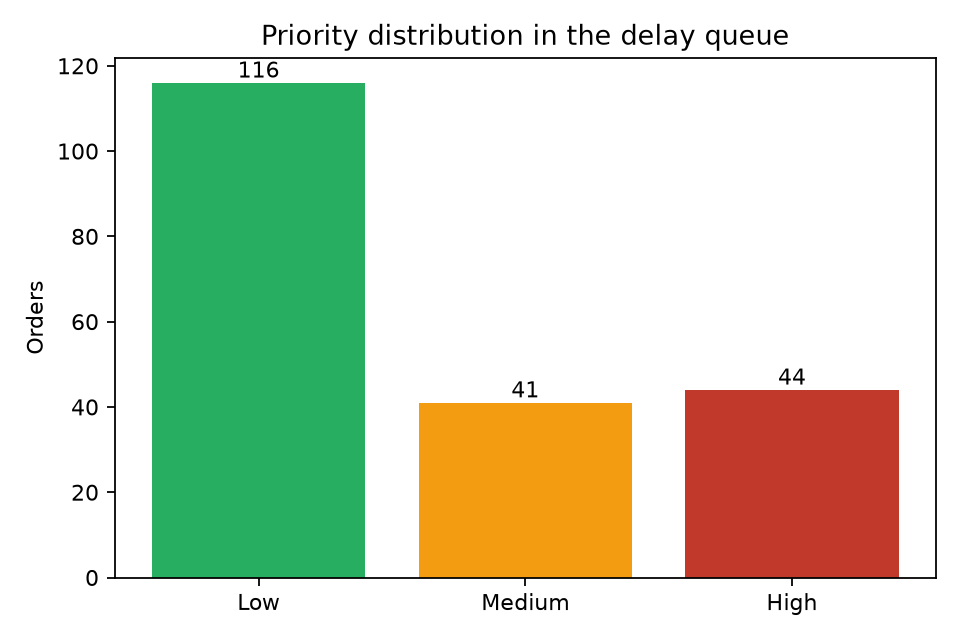

In [5]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "priority_distribution.png"))

**Insight (hình).** Phần lớn đơn ở Low/Medium; nhóm High là thiểu số cần can thiệp — đúng tinh thần phân bổ nguồn lực có trọng tâm.

### 1a. Bóc tách công thức Risk Score (ví dụ tính tay)

**Vì sao bước này?**
- Làm gì: Trình bày cách tính `delay_risk_score` (từ 0-100) bằng cách cộng dồn điểm dự báo của model (trọng số 0.55) với các hình phạt (pressure) từ vận hành thực tế như distance (0.12), traffic (0.15), v.v. Lấy một đơn test thật, tính từng thành phần × trọng số = đóng góp, để thấy điểm số đến từ đâu.
- Vì sao: Để hệ thống DSS không phải là một "hộp đen" (black box). Các trọng số này do chuyên gia/nghiệp vụ quy định nhằm cân bằng giữa AI và logic kinh doanh. Bóc tách ra giúp người điều phối hiểu chính xác vì sao đơn này bị điểm rủi ro cao.
- Kỹ thuật: Heuristic Weighting, Explainable Rules.
- Bằng chứng dẫn tới: Bảng breakdown cho thấy tổng `contribution` của các thành phần khớp 100% với `delay_risk_score`. Điểm số được minh bạch hoàn toàn.

In [6]:
_, _, test_df = load_processed_splits()
model = load_best_model()
probs = predict_delay_probability(model, test_df)
order = test_df.iloc[0]
p = float(probs[0])
components = calculate_delay_risk_components(order, p)
weights = {"model_probability": 0.55, "traffic_pressure": 0.15, "distance_pressure": 0.12,
           "peak_pressure": 0.08, "complexity_pressure": 0.06, "weekend_pressure": 0.04}
breakdown = pd.DataFrame([
    {"component": k, "value": round(components[k], 2), "weight": w,
     "contribution": round(components[k] * w, 2)}
    for k, w in weights.items()
])
breakdown

,component,value,weight,contribution
0,model_probability,17.9,0.55,9.85
1,traffic_pressure,100.0,0.15,15.00
2,distance_pressure,50.0,0.12,6.00
3,peak_pressure,100.0,0.08,8.00
4,complexity_pressure,60.0,0.06,3.60
5,weekend_pressure,40.0,0.04,1.60


In [7]:
pd.DataFrame(explain_delay_risk_score(order, p))[[
    "component", "component_score", "weight", "weighted_contribution",
    "score_formula", "normalization", "rationale"
]]

,component,component_score,weight,weighted_contribution,score_formula,normalization,rationale
0,model_probability,17.9034,0.55,9.8468,delayed_probability * 100,Xác suất trễ từ model được đổi từ 0-1 sang 0-100.,Tín hiệu học máy là bằng chứng chính nên chiếm...
1,traffic_pressure,100.0000,0.15,15.0000,"Low=20, Medium=60, High=100",Traffic ordinal được ánh xạ thành áp lực vận h...,Traffic là driver rủi ro rõ trong EDA và tác đ...
2,distance_pressure,50.0000,0.12,6.0000,"min(distance_km / 10 * 100, 100)","10 km là mức xa nhất trong dữ liệu, nên distan...","Đơn càng xa càng ít buffer, nhưng vẫn thấp hơn..."
3,peak_pressure,100.0000,0.08,8.0000,"100 nếu peak hour, ngược lại 20","Peak hour là cờ nhị phân, đổi thành mức áp lực...",Giờ cao điểm ảnh hưởng năng lực vận hành nhưng...
4,complexity_pressure,60.0000,0.06,3.6000,"min(pizza_complexity / 20 * 100, 100)","Pizza complexity tối đa quan sát là 20, nên sc...","Đơn phức tạp có thể làm chuẩn bị lâu hơn, dùng..."
5,weekend_pressure,40.0000,0.04,1.6000,"70 nếu weekend, ngược lại 40","Weekend là cờ nhị phân, đổi thành áp lực vừa/c...","Weekend là yếu tố phụ, giữ trọng số nhỏ vì aud..."


In [8]:
{
    "order_id": order["order_id"],
    "model_probability": round(p, 4),
    "delay_risk_score": calculate_delay_risk_score(order, p),
    "priority": get_priority_level(calculate_delay_risk_score(order, p)),
}

{'order_id': 'ORD002',
 'model_probability': 0.179,
 'delay_risk_score': 44.0,
 'priority': 'Medium'}

In [9]:
pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "risk_component_breakdown.csv").head(18)

,section,order_id,component,weight,mean_contribution,mean_component_score
0,overall_mean_contribution,ALL,model_probability,0.55,14.156370,25.738844
1,overall_mean_contribution,ALL,traffic_pressure,0.15,9.507463,63.383085
2,overall_mean_contribution,ALL,distance_pressure,0.12,5.903881,49.199005
3,overall_mean_contribution,ALL,peak_pressure,0.08,7.808955,97.611940
4,overall_mean_contribution,ALL,complexity_pressure,0.06,2.774627,46.243781
5,overall_mean_contribution,ALL,weekend_pressure,0.04,1.970149,49.253731
6,top_priority_orders,ORD271,model_probability,0.55,54.994200,99.989400
7,top_priority_orders,ORD271,traffic_pressure,0.15,15.000000,100.000000
8,top_priority_orders,ORD271,distance_pressure,0.12,12.000000,100.000000
9,top_priority_orders,ORD271,peak_pressure,0.08,8.000000,100.000000


**Insight.** Tổng `contribution` đúng bằng `delay_risk_score`; thành phần xác suất mô hình (0.55) chi phối, các áp lực vận hành tinh chỉnh thêm. Nhờ vậy mỗi điểm số đều *giải thích được* cho người vận hành.

### 1b. Kiểm chứng calibration: risk cao có trễ thật nhiều hơn?

**Vì sao bước này?**
- Làm gì: Nhóm dữ liệu theo 3 dải rủi ro (Low, Medium, High) được tạo ra từ Risk Score, sau đó đo lường tỷ lệ trễ thực tế (`actual_delay_rate`) của từng nhóm trên tập Test.
- Vì sao: Do Risk Score bị can thiệp bằng heuristic (cộng điểm phạt giao thông, khoảng cách), ta phải kiểm chứng lại xem điểm này có còn bám sát với tỷ lệ trễ thật hay không (Calibration). Nếu nhóm "High" mà tỷ lệ trễ thật lại thấp hơn nhóm "Medium" thì DSS đã hoạt động sai.
- Kỹ thuật: Probability Calibration, Binning.
- Bằng chứng dẫn tới: Kết quả `actual_delay_rate` tăng dần một cách rõ rệt từ Low -> Medium -> High, chứng minh công thức Risk Score hợp lý và hoạt động đúng hướng so với thực tế.

In [10]:
pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "risk_calibration.csv")

,risk_band,orders,actual_delayed,actual_delay_rate,mean_risk_score,mean_predicted_probability,monotonic_from_previous
0,Low,116,0,0.000000,23.827586,0.017317,True
1,Medium,41,3,0.073171,44.931707,0.209461,True
2,High,44,39,0.886364,87.729545,0.934955,True


**Insight (calibration).** `actual_delay_rate` tăng dần Low → Medium → High ⇒ Risk Score xếp hạng rủi ro đúng hướng với thực tế trên test. Đây là bằng chứng tầng DSS không chỉ đẹp về hình thức mà còn bám outcome.

### 1c. Độ nhạy ngưỡng priority

**Vì sao bước này?**
- Làm gì: Khảo sát việc thay đổi cặp ngưỡng cắt Low/Medium/High (ví dụ: 30/60, 35/65, 40/70) làm thay đổi số lượng đơn hàng lọt vào từng nhóm như thế nào.
- Vì sao: Các con số 35 và 65 (trong `config.py`) không phải là chân lý tuyệt đối mà là "chính sách". Nó phụ thuộc vào *năng lực xử lý* của cửa hàng. Bằng cách thử nhiều ngưỡng, ta cho thấy hệ thống rất linh hoạt: nếu cửa hàng đang bận, họ có thể nâng ngưỡng lên 40/70 để chỉ tập trung vào các đơn rủi ro nguy cấp nhất.
- Kỹ thuật: Sensitivity Analysis.
- Bằng chứng dẫn tới: Sự phân bổ số đơn vào nhóm High thay đổi rõ rệt khi thay đổi ngưỡng, minh chứng cho việc DSS cung cấp một công cụ "vặn núm" điều phối cho người dùng thay vì code cứng một giá trị.

In [11]:
pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "priority_threshold_sensitivity.csv")

,scenario,low_cut,high_cut,low_orders,medium_orders,high_orders,high_actual_delayed,high_delay_rate,captured_delayed_share
0,tighter_capacity,30,60,97,57,47,40,0.851064,0.952381
1,locked_policy,35,65,116,41,44,39,0.886364,0.928571
2,looser_capacity,40,70,129,31,41,38,0.926829,0.904762


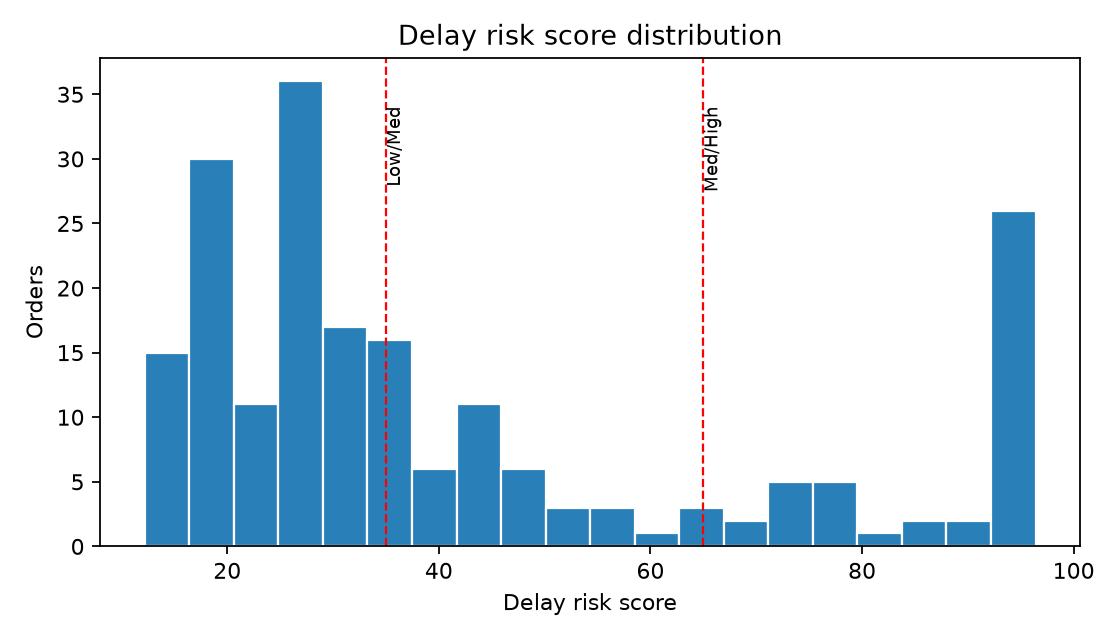

In [12]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "risk_score_histogram.png"))

**Insight (độ nhạy).** Số đơn High thay đổi theo ngưỡng — đây là *lựa chọn năng lực xử lý*, không phải sự thật khách quan. Báo cáo nêu rõ ngưỡng 35/65 là chính sách có thể điều chỉnh theo nguồn lực thực.

## 2. Bài toán vận tải / phân công

**Vì sao bước này?**
- Làm gì: Giải quyết bài toán phân công (Assignment Problem): Làm sao để gán các đơn hàng rủi ro cao cho các tài xế (đang giả lập) để tổng chi phí giao hàng là thấp nhất.
- Vì sao: Bước này là đại diện của tầng Prescriptive (đề xuất hành động). Thay vì để con người tự gán bừa tài xế, ta dùng thuật toán tối ưu. Nếu môi trường có `scipy`, nó dùng thuật toán **Hungarian** để tìm phương án tối ưu toàn cục. Nếu không, nó sẽ fallback sang thuật toán **Greedy** (tham lam) làm giải pháp thay thế.
- Kỹ thuật: Linear Sum Assignment (Hungarian Algorithm), Greedy Heuristic.
- Bằng chứng dẫn tới: Tính toán dựa trên một ma trận chi phí (cost matrix) mô phỏng: thời gian đi đường + hình phạt rủi ro trễ + thưởng nếu cùng tuyến. Hàm tối ưu hóa đảm bảo tìm được tổng cost nhỏ nhất có thể, đưa ra khuyến nghị thực tế (actionable recommendation).

In [13]:
pd.DataFrame(transport_cost_policy_spec())

,term,formula,source,effect
0,travel_minutes,distance_km * 3.2 / driver_speed_factor,distance_km từ đơn thật; speed_factor từ fleet...,Đơn xa hoặc tài xế chậm hơn có cost cao hơn.
1,priority_penalty,0.35 * (100 - delay_risk_score),delay_risk_score từ queue DSS,Đơn risk càng cao thì penalty càng thấp để đượ...
2,high_traffic_penalty,"6 nếu traffic_level == 'High', ngược lại 0",traffic_level từ đơn thật,Traffic cao làm tăng cost vì cần thêm buffer v...
3,same_location_bonus,"-8 nếu order.location == driver.base_location,...",location từ đơn thật; base_location từ fleet g...,Ưu tiên tài xế cùng khu vực để giảm chi phí pr...
4,cost_floor,max(travel + priority + traffic - same_locatio...,quy tắc an toàn của mô hình cost,Đảm bảo cost không âm khi có bonus cùng khu vực.


**Đọc bảng cost policy.** `distance_km`, `traffic_level` và
`delay_risk_score` đến từ đơn/queue thật; `speed_factor`,
`base_location` và `capacity` là giả lập vì dataset không có bảng tài
xế. Vì vậy assignment là demo prescriptive DSS, không phải mô hình
dispatch sản xuất.

In [14]:
summary = build_transport_artifacts()
summary

{'scenario_type': 'simulated_driver_fleet_on_real_orders',
 'assigned_orders': 12,
 'drivers': 6,
 'total_capacity': 12,
 'mean_assignment_cost': 32.84,
 'high_priority_assigned': 12,
 'algorithm': 'Hungarian linear sum assignment; greedy fallback if scipy is unavailable',
 'cost_formula': 'distance_km*3.2/speed_factor + 0.35*(100-risk_score) + high_traffic_penalty - same_location_bonus, floored at 0',
 'note': 'Drivers/capacity are simulated because the Kaggle dataset has no driver table.'}

In [15]:
assignments = solve_transport_assignment(top_n=12)
assignments

,order_id,restaurant_name,location,traffic_level,distance_km,delay_risk_score,priority,driver_id,driver_slot,driver_base_location,estimated_assignment_cost
0,ORD271,Marco's Pizza,"Miami, FL",High,10.0,96.4,High,D04,D04-1,"Miami, FL",31.26
1,ORD361,Marco's Pizza,"Boston, MA",High,10.0,96.4,High,D06,D06-1,"Boston, MA",30.63
2,ORD581,Domino's,"Austin, TX",High,10.0,96.4,High,D03,D03-1,"Chicago, IL",37.74
3,ORD128,Pizza Hut,"Los Angeles, CA",High,8.0,96.3,High,D02,D02-1,"Los Angeles, CA",26.24
4,ORD539,Little Caesars,"Garland, TX",High,8.0,96.2,High,D01,D01-1,"New York, NY",32.93
5,ORD609,Little Caesars,"Dallas, TX",High,8.0,96.2,High,D05,D05-1,"Dallas, TX",25.45
6,ORD417,Pizza Hut,"Los Angeles, CA",High,8.0,96.1,High,D02,D02-2,"Los Angeles, CA",26.31
7,ORD319,Pizza Hut,"San Diego, CA",High,8.0,95.9,High,D04,D04-2,"Miami, FL",33.03
8,ORD574,Little Caesars,"Houston, TX",High,8.0,95.7,High,D05,D05-2,"Dallas, TX",33.63
9,ORD564,Domino's,"Baltimore, MD",High,10.0,95.2,High,D01,D01-2,"New York, NY",39.68


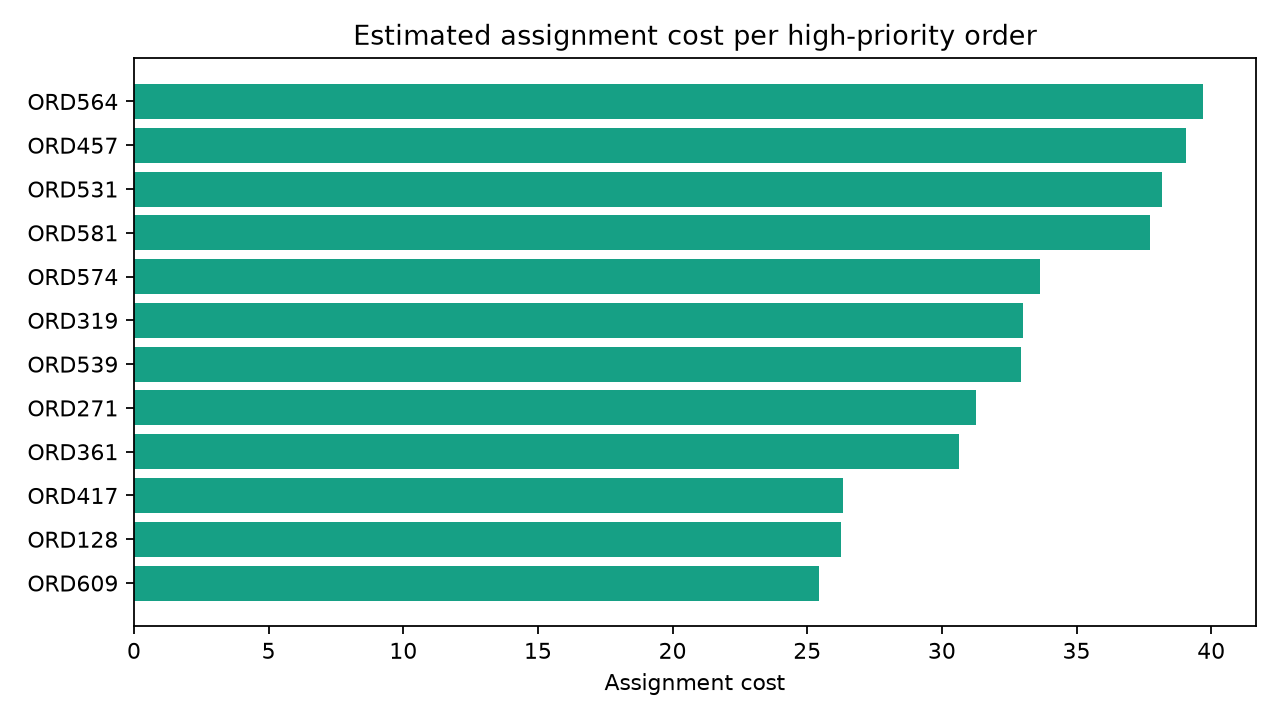

In [16]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "transport_assignment_cost.png"))

**Insight.** Chi phí gán = thời gian di chuyển (theo distance/speed) +
phạt ưu tiên + phạt traffic cao − bonus cùng khu vực. Hungarian chọn
tổ hợp gán **tổng chi phí nhỏ nhất**; greedy là phương án dự phòng nếu
thiếu scipy. **Lưu ý:** đơn hàng là thật nhưng driver/capacity là *giả
lập* vì dataset không có bảng tài xế — đây là minh hoạ prescriptive.

## 3. Power BI-ready pack

In [17]:
build_powerbi_pack()

{'tables': ['fact_orders.csv',
  'fact_delay_queue.csv',
  'fact_transport_assignment.csv',
  'fact_monthly_demand_forecast.csv',
  'fact_hourly_staffing_plan.csv',
  'fact_recommendation_rules.csv',
  'fact_hypothesis_tests.csv',
  'fact_data_realism_audit.csv',
  'fact_risk_component_policy.csv',
  'fact_transport_cost_policy.csv',
  'fact_product_type_mix.csv',
  'fact_product_size_mix.csv',
  'fact_top_restaurant_by_type.csv',
  'fact_redundant_feature_audit.csv',
  'dim_restaurant.csv',
  'dim_location.csv',
  'dim_date.csv'],
 'dax': 'measures.dax',
 'dashboard_spec': 'dashboard_spec.md',
 'build_guide': 'POWERBI_BUILD_GUIDE.md',
 'note': 'Create the .pbix manually in Power BI Desktop using this pack.'}

In [18]:
sorted([p.name for p in (PROJECT_ROOT / "powerbi").iterdir()])

['POWERBI_BUILD_GUIDE.md',
 'README.md',
 'dashboard_spec.md',
 'dim_date.csv',
 'dim_location.csv',
 'dim_restaurant.csv',
 'fact_data_realism_audit.csv',
 'fact_delay_queue.csv',
 'fact_hourly_staffing_plan.csv',
 'fact_hypothesis_tests.csv',
 'fact_monthly_demand_forecast.csv',
 'fact_orders.csv',
 'fact_product_size_mix.csv',
 'fact_product_type_mix.csv',
 'fact_recommendation_rules.csv',
 'fact_redundant_feature_audit.csv',
 'fact_risk_component_policy.csv',
 'fact_top_restaurant_by_type.csv',
 'fact_transport_assignment.csv',
 'fact_transport_cost_policy.csv',
 'manifest.json',
 'measures.dax']

**Insight.** Pack gồm bảng fact (orders, delay_queue, transport,
forecast, staffing, rules, audit, mix) + dim (restaurant, location,
date) + `measures.dax` + spec. Đây là **data pack** để dựng `.pbix`
trong Power BI Desktop, chưa phải file `.pbix` sẵn.

## 4. Insight → quyết định tầng DSS

In [19]:
pd.DataFrame([
    {"cau_hoi": "Risk Score lấy ở đâu?", "bang_chung": "Tổng contribution = score; model prob chiếm 0.55.",
     "quyet_dinh": "Trình bày như chính sách minh bạch, bóc tách được, không phải nhãn học."},
    {"cau_hoi": "Risk có đúng thực tế?", "bang_chung": "actual_delay_rate tăng theo risk band.",
     "quyet_dinh": "Dùng Risk Score để xếp hàng đợi; vẫn nêu là hỗ trợ, không tự động điều phối."},
    {"cau_hoi": "Ngưỡng 35/65 cố định?", "bang_chung": "Số đơn High đổi theo ngưỡng.",
     "quyet_dinh": "Coi ngưỡng là tham số theo năng lực xử lý, ghi rõ trong báo cáo."},
    {"cau_hoi": "Tối ưu vận tải thật chưa?", "bang_chung": "Không có bảng tài xế thật.",
     "quyet_dinh": "Giữ là kịch bản giả lập; không tuyên bố tối ưu dispatch thực tế."},
])

,cau_hoi,bang_chung,quyet_dinh
0,Risk Score lấy ở đâu?,Tổng contribution = score; model prob chiếm 0.55.,"Trình bày như chính sách minh bạch, bóc tách đ..."
1,Risk có đúng thực tế?,actual_delay_rate tăng theo risk band.,Dùng Risk Score để xếp hàng đợi; vẫn nêu là hỗ...
2,Ngưỡng 35/65 cố định?,Số đơn High đổi theo ngưỡng.,"Coi ngưỡng là tham số theo năng lực xử lý, ghi..."
3,Tối ưu vận tải thật chưa?,Không có bảng tài xế thật.,Giữ là kịch bản giả lập; không tuyên bố tối ưu...
